(-0.5, 909.5, 1327.5, -0.5)

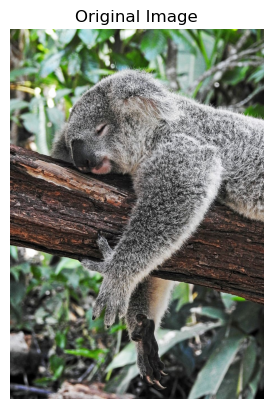

In [1]:
import numpy as np
import cv2 as cv
import math
import matplotlib.pyplot as plt

img_bgr = cv.imread(r"C:\Users\rithi\Downloads\kola bear.jpg")
img = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)
plt.imshow(img)
plt.title("Original Image")
plt.axis('off')


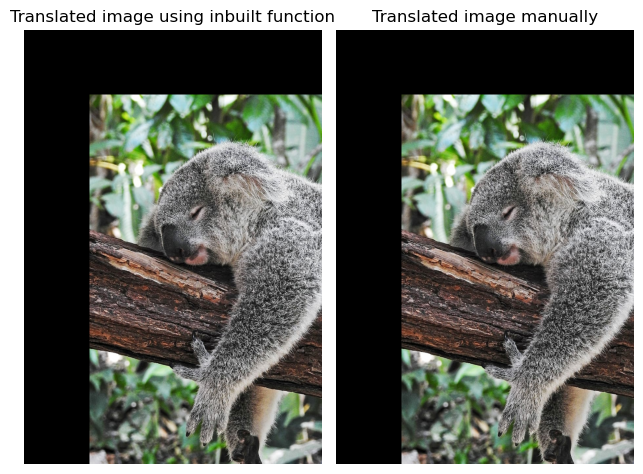

In [2]:
rows, cols, _ = img.shape
#Translation using inbuilt function
dst_fun= np.zeros_like(img)
M = np.float32([[1, 0, 200], [0, 1, 200]])
dst_fun = cv.warpAffine(img, M, (cols, rows))

# Create an empty output image
dst_man = np.zeros_like(img)

# Apply the affine transformation manually
for i in range(rows):
    for j in range(cols):
        # Calculate the new coordinates
        new_x = int(M[0, 0] * j + M[0, 1] * i + M[0, 2])
        new_y = int(M[1, 0] * j + M[1, 1] * i + M[1, 2])
        
        # Check if the new coordinates are within the image bounds
        if 0 <= new_x < cols and 0 <= new_y < rows:
            dst_man[new_y, new_x] = img[i, j]
plt.subplot(1,2,1)
plt.imshow(dst_fun)
plt.title('Translated image using inbuilt function')
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(dst_man)
plt.title('Translated image manually')
plt.axis('off')
plt.tight_layout()
plt.show()

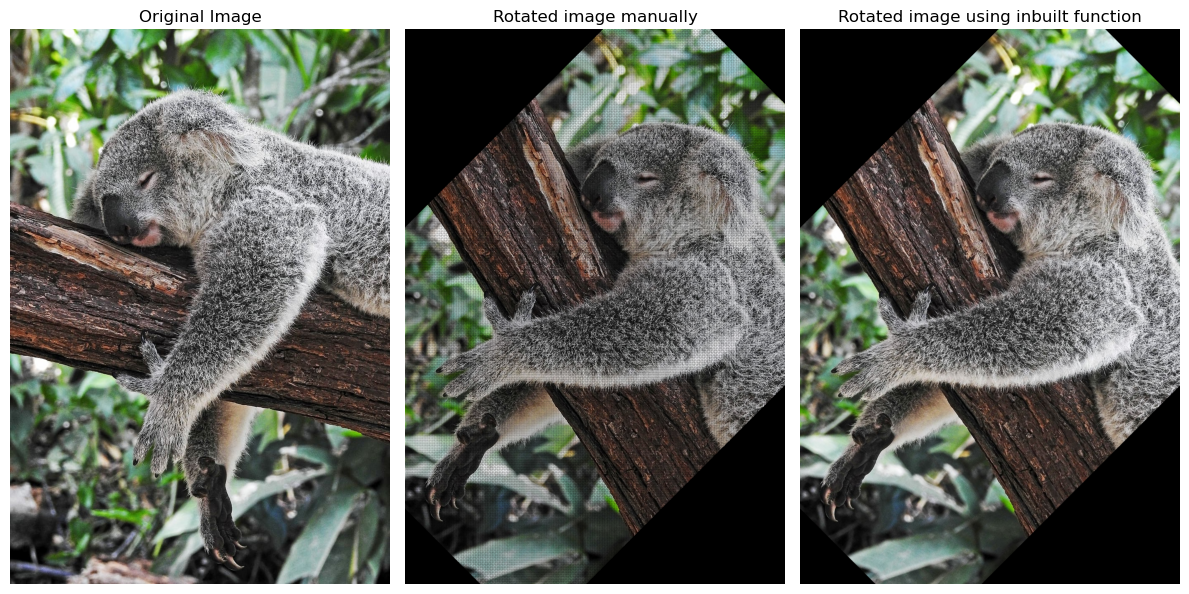

In [3]:
rotated_img_man = np.zeros_like(img)
rotated_img_fun = np.zeros_like(img)

# Define the rotation angle (in degrees)
angle_fun = -45
angle_man = 45
angle_rad = math.radians(angle_man)
# Calculate the center of the image
center = (cols // 2, rows // 2)

for i in range(rows):
    for j in range(cols):
        # Calculate the coordinates relative to the center
        x = j - center[0]
        y = i - center[1]
        
        # Calculate the new coordinates using the rotation matrix
        new_x = int(center[0] + (x * math.cos(angle_rad) - y * math.sin(angle_rad)))
        new_y = int(center[1]+ (x * math.sin(angle_rad) + y * math.cos(angle_rad)))
        
        # Check if the new coordinates are within the image bounds
        if 0 <= new_x < cols and 0 <= new_y < rows:
            rotated_img_man[new_y, new_x] = img[i, j]

# Get the rotation matrix using getRotationMatrix2D
M = cv.getRotationMatrix2D(center, angle_fun, 1.0)

# Perform the rotation using warpAffine
rotated_img_fun = cv.warpAffine(img, M, (cols, rows))

plt.figure(figsize = (12,8))
plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis('off')


plt.subplot(1,3,2)
plt.imshow(rotated_img_man)
plt.title('Rotated image manually')
plt.axis('off')

plt.subplot(1,3,3)

# Display the result
plt.imshow(rotated_img_fun)
plt.title('Rotated image using inbuilt function')
plt.axis('off')

plt.tight_layout()
plt.show()

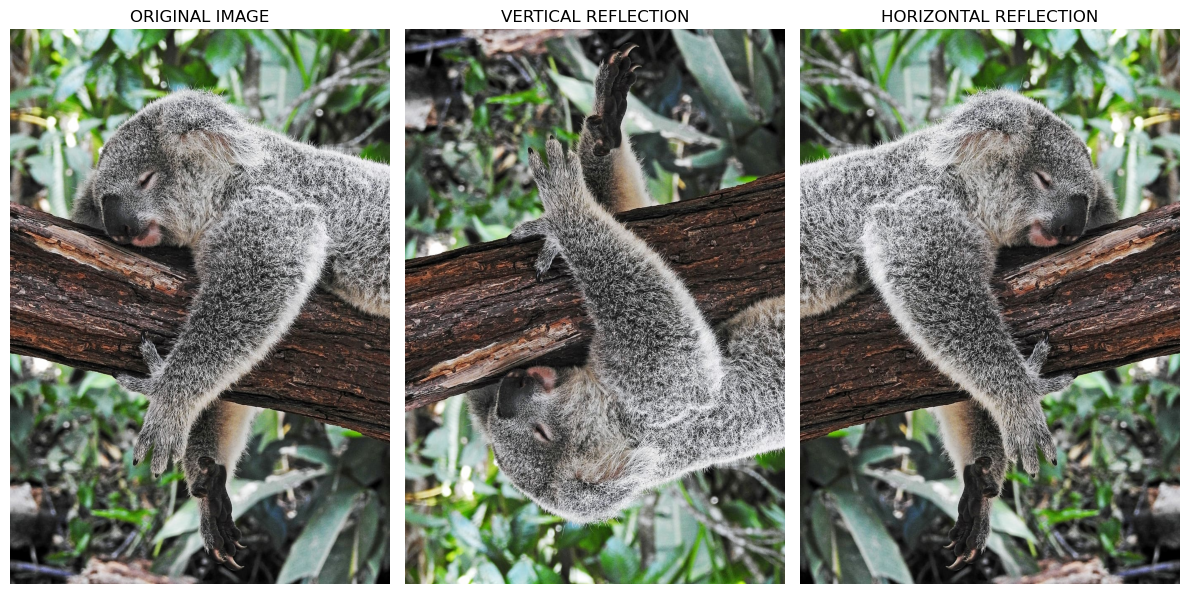

In [4]:


# Create an empty output image for horizontal reflection
horizontal_reflection = np.zeros_like(img)
vertical_reflection = np.zeros_like(img)

# Perform horizontal reflection manually
for i in range(rows):
    for j in range(cols):
        horizontal_reflection[i, cols - 1 - j] = img[i, j]
        vertical_reflection[rows - 1 - i, j] = img[i, j]

# Display the result
plt.figure(figsize = (12,8))
plt.subplot(1,3,1)
plt.imshow(img)
plt.title("ORIGINAL IMAGE")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(horizontal_reflection)
plt.title('HORIZONTAL REFLECTION')
plt.axis('off')

plt.subplot(1,3,2)

# Display the result
plt.imshow(vertical_reflection)
plt.title('VERTICAL REFLECTION')
plt.axis('off')
plt.tight_layout()
plt.show()


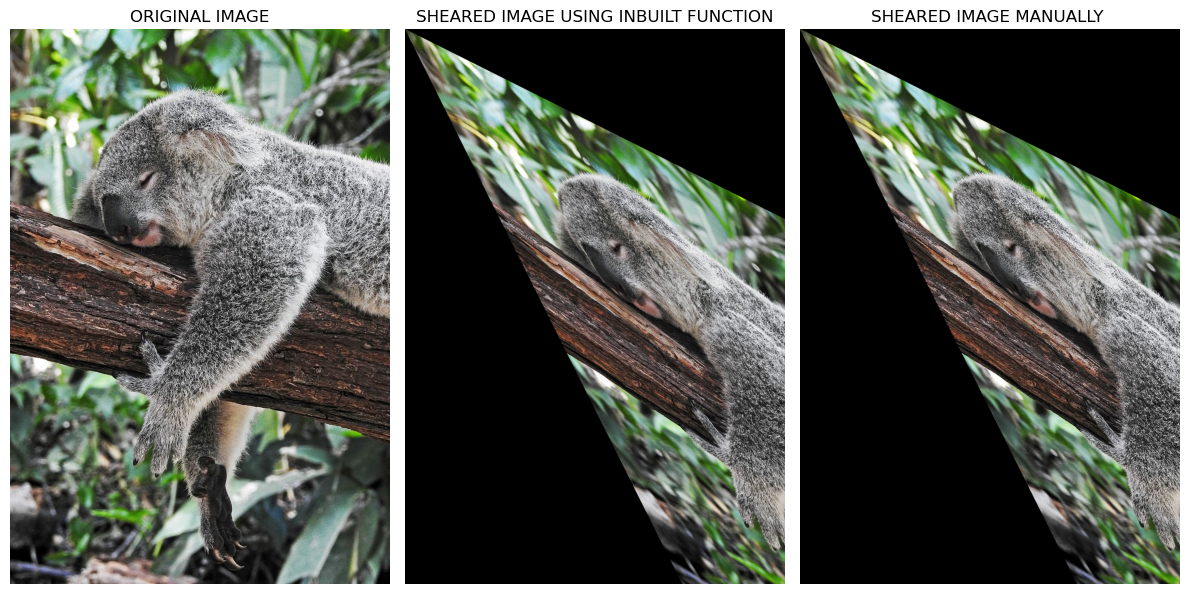

In [5]:
# Define the shearing factors
shear_factor_x = 0.5  # Shearing factor along the x-axis
shear_factor_y = 0.5 # Shearing factor along the y-axis

sheared_img_man = np.zeros_like(img)
sheared_img_fun = np.zeros_like(img)


# Create the shearing matrix
M = np.float32([
    [1, shear_factor_x, 0],
    [shear_factor_y, 1, 0]
])

# Perform the shearing using warpAffine
sheared_img_fun = cv.warpAffine(img, M, (cols, rows))

# Perform the shearing manually
for i in range(rows):
    for j in range(cols):
        # Calculate the new coordinates using the shearing matrix
        new_x = int(j + shear_factor_x * i)
        new_y = int(i + shear_factor_y * j)
        
        # Check if the new coordinates are within the image bounds
        if 0 <= new_x < cols and 0 <= new_y < rows:
            sheared_img_man[new_y, new_x] = img[i, j]

# Display the result
plt.figure(figsize=(12, 8))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("ORIGINAL IMAGE")
plt.axis('off')

plt.subplot(1, 3,2)
plt.imshow(sheared_img_fun)
plt.title('SHEARED IMAGE USING INBUILT FUNCTION')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(sheared_img_man)
plt.title('SHEARED IMAGE MANUALLY ')
plt.axis('off')


plt.tight_layout()
plt.show()


(-0.5, 909.5, 1327.5, -0.5)

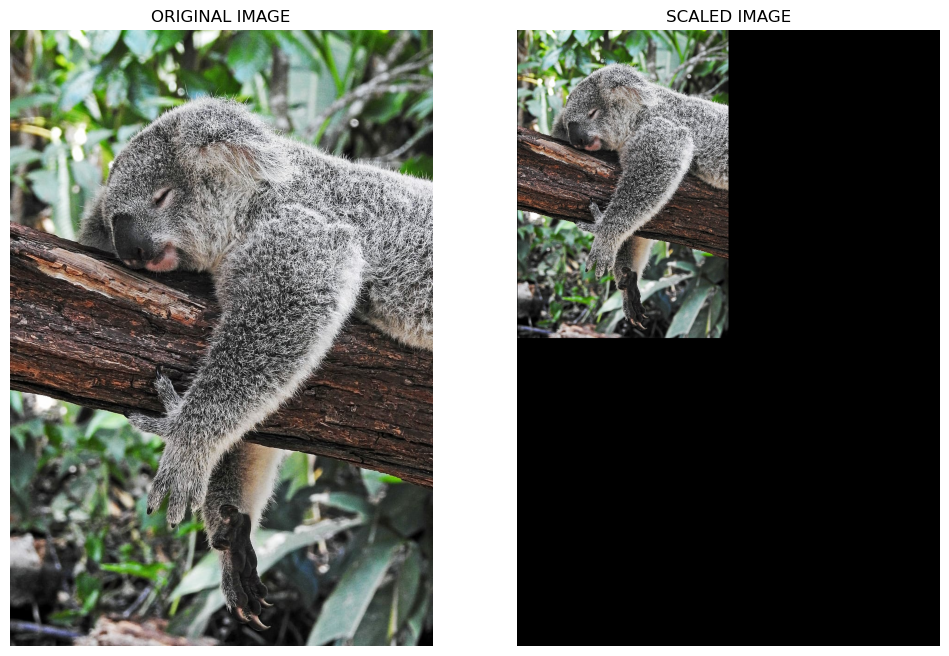

In [6]:
sca_img = np.zeros_like(img)
s_x=0.5
s_y = 0.5
for i in range(rows):
    for j in range (cols):
        x1=int(s_x*i)
        y1=int(s_x*j)
        if 0<=x1<rows and 0<y1<cols:
              sca_img[x1,y1] =img[i,j]
            
plt.figure(figsize=(12, 8))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("ORIGINAL IMAGE")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(sca_img)
plt.title("SCALED IMAGE")
plt.axis('off')